In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

xlsx_file = "alimarko_vs_vhg_contig_blast.xlsx"

df = pd.read_excel(xlsx_file)

print(df.shape)
df.head()

(1195, 14)


,VHG контиг,"Длина контига VHG, нукл.",AliMarko контиг,"Длина контига AliMarko, нукл.",Начало контига VHG,Конец контига VHG,Начало контига AliMarko,Конец контига AliMarko,"Длина выравнивания, нукл.","Процент идентичности, %","Покрытие контига VHG, %",Мисматчей,Открытие гэпа,Битскор
0,SRR14381429_cap3_Contig-2,10510,k141_18829,9310,1,135,135,1,135,100.0,1,0,0,250.0
1,SRR14381429_cap3_Contig-4,7738,k141_14601,8438,7675,7738,6723,6660,64,100.0,1,0,0,119.0
2,SRR14381429_cap3_Contig-10,5586,k141_9267,5555,1,5555,1,5555,5555,100.0,99,0,0,10259.0
3,SRR14381429_cap3_Contig-14,4630,k141_16661,6888,48,80,43,75,33,100.0,1,0,0,62.1
4,SRR14381429_cap3_Contig-16,4492,k141_17975,7045,1,4492,6793,2302,4492,100.0,100,0,0,8296.0


In [25]:
df["Покрытие контига AliMarko, %"] = (
    (df["Конец контига AliMarko"] - df["Начало контига AliMarko"]).abs() + 1
) / df["Длина контига AliMarko, нукл."] * 100

df["Score"] = (df["Процент идентичности, %"] * df["Покрытие контига VHG, %"] * df["Длина выравнивания, нукл."]) / 10000

df_best = (
    df.sort_values(
        ["Score"],
        ascending=False
    )
    .drop_duplicates(subset="VHG контиг", keep="first")
    .reset_index(drop=True)
)

print("Исходных строк:", len(df))
print("Лучших хитов:", len(df_best))

df_best.head()

Исходных строк: 1195
Лучших хитов: 195


,VHG контиг,"Длина контига VHG, нукл.",AliMarko контиг,"Длина контига AliMarko, нукл.",Начало контига VHG,Конец контига VHG,Начало контига AliMarko,Конец контига AliMarko,"Длина выравнивания, нукл.","Процент идентичности, %","Покрытие контига VHG, %",Мисматчей,Открытие гэпа,Битскор,"Покрытие контига AliMarko, %",Score
0,SRR14381429_cap3_Contig-2,10510,k141_3888,9971,688,9897,9971,765,9227,88.696,88,1006,32,11226.0,92.337780,7201.902330
1,SRR14381429_cap3_Contig-5,7030,k141_3378,10619,44,7030,3633,10619,6987,99.986,99,1,0,12898.0,65.797156,6916.161602
2,SRR14381429_cap3_Contig-4,7738,k141_9498,9261,19,7679,9261,1601,7663,88.099,99,908,4,9095.0,82.723248,6683.516106
3,SRR14381429_cap3_Contig-8,6168,k141_13289,8021,146,6167,6021,1,6022,99.851,98,8,1,11069.0,75.065453,5892.766676
4,SRR14381429_cap3_Contig-7,6236,k141_3888,9971,1,6234,7217,984,6237,90.669,99,576,6,8288.0,62.521312,5598.475275


In [26]:
df_best.to_excel(
    "alimarko_vs_vhg_best_hits.xlsx",
    index=False
)

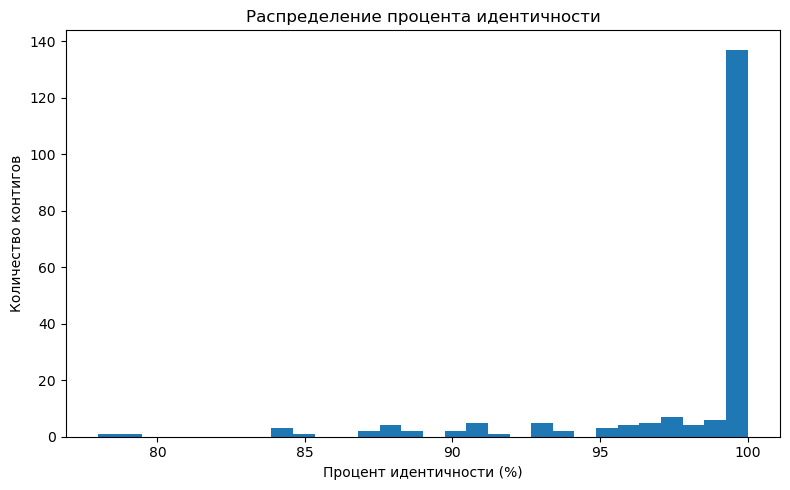

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_best["Процент идентичности, %"],
    bins=30
)

plt.xlabel("Процент идентичности (%)")
plt.ylabel("Количество контигов")
plt.title("Распределение процента идентичности")

plt.tight_layout()
plt.show()

In [28]:
x = df_best[df_best["Процент идентичности, %"] > 95]["Процент идентичности, %"].value_counts()

In [29]:
from Bio import SeqIO

vhg_ids = set(df_best["VHG контиг"])

input_fasta = "VHG_SRR14381429_contigs.fasta"
output_fasta = "VHG_SRR14381429_contigs_filtered.fasta"

records = (
    rec for rec in SeqIO.parse(input_fasta, "fasta")
    if rec.id in vhg_ids
)

count = SeqIO.write(records, output_fasta, "fasta")

print("Сохранено VHG контигов:", count)

Сохранено VHG контигов: 195


In [30]:
alimarko_ids = set(df_best["AliMarko контиг"])

input_fasta = "alimarko_SRR14381429_contigs.fasta"
output_fasta = "alimarko_SRR14381429_contigs_filtered.fasta"

records = (
    rec for rec in SeqIO.parse(input_fasta, "fasta")
    if rec.id in alimarko_ids
)

count = SeqIO.write(records, output_fasta, "fasta")

print("Сохранено AliMarko контигов:", count)

Сохранено AliMarko контигов: 135


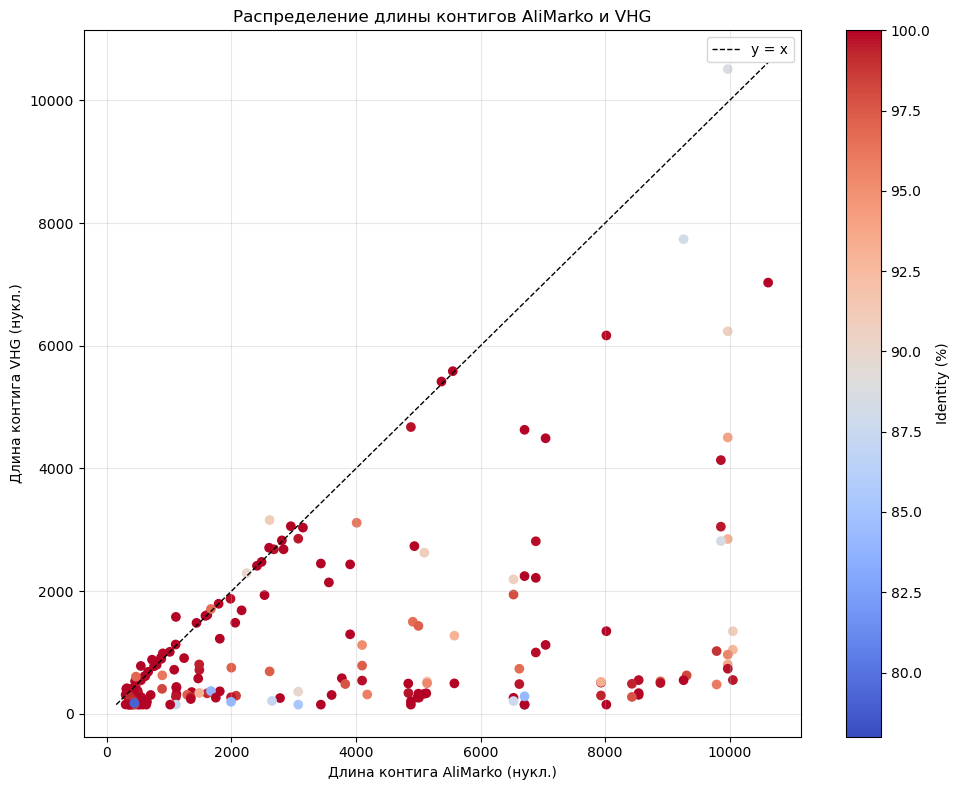

In [31]:
plt.figure(figsize=(10, 8))

sc = plt.scatter(
    df_best["Длина контига AliMarko, нукл."],
    df_best["Длина контига VHG, нукл."],
    c=df_best["Процент идентичности, %"],
    cmap="coolwarm",
    alpha=1.0
)

xmin = min(
    df_best["Длина контига AliMarko, нукл."].min(),
    df_best["Длина контига VHG, нукл."].min()
)

xmax = max(
    df_best["Длина контига AliMarko, нукл."].max(),
    df_best["Длина контига VHG, нукл."].max()
)

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    "--",
    color="black",
    linewidth=1,
    label="y = x"
)

cbar = plt.colorbar(sc)
cbar.set_label("Identity (%)")

plt.xlabel("Длина контига AliMarko (нукл.)")
plt.ylabel("Длина контига VHG (нукл.)")

plt.title("Распределение длины контигов AliMarko и VHG")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = go.FigureWidget()

scatter = fig.add_scatter(
    x=df_best["Длина контига AliMarko, нукл."],
    y=df_best["Длина контига VHG, нукл."],
    mode="markers",
    marker=dict(
        size=8,
        color=df_best["Процент идентичности, %"],
        colorscale="tealrose",
        showscale=True,
        colorbar=dict(title="Identity (%)")
    ),
    text=df_best.apply(lambda row: f"<b>VHG контиг:</b> {row['VHG контиг']}<br>"
                                   f"<b>AliMarko контиг:</b> {row['AliMarko контиг']}<br>"
                                   f"<b>Identity:</b> {row['Процент идентичности, %']:.2f}%<br>"
                                   f"<b>Покрытие VHG:</b> {row['Покрытие контига VHG, %']:.2f}%<br>"
                                   f"<b>Мисматчей:</b> {row['Мисматчей']}<br>"
                                   f"<b>Битскор:</b> {row['Битскор']}",
                       axis=1),
    hoverinfo="text"
)

xmin = min(df_best["Длина контига AliMarko, нукл."].min(), 
           df_best["Длина контига VHG, нукл."].min())
xmax = max(df_best["Длина контига AliMarko, нукл."].max(), 
           df_best["Длина контига VHG, нукл."].max())

fig.add_scatter(
    x=[xmin, xmax],
    y=[xmin, xmax],
    mode="lines",
    line=dict(dash="dash", color="black", width=1),
    name="y = x",
    hoverinfo="skip"
)

fig.update_layout(
    title="Распределение длины контигов AliMarko и VHG",
    xaxis_title="Длина контига AliMarko (нукл.)",
    yaxis_title="Длина контига VHG (нукл.)",
    width=1800,
    height=1300,
    hovermode="closest"
)

fig.show()

FigureWidget({
    'data': [{'hoverinfo': 'text',
              'marker': {'color': {'bdata': ('BoGVQ4ssVkDJdr6fGv9YQHWTGARWBl' ... 'WbxCAIVUAAAAAAAABZQAAAAAAAAFlA'),
                                   'dtype': 'f8'},
                         'colorbar': {'title': {'text': 'Identity (%)'}},
                         'colorscale': [[0.0, 'rgb(0, 147, 146)'],
                                        [0.16666666666666666, 'rgb(114, 170,
                                        161)'], [0.3333333333333333, 'rgb(177, 199,
                                        179)'], [0.5, 'rgb(241, 234, 200)'],
                                        [0.6666666666666666, 'rgb(229, 185, 173)'],
                                        [0.8333333333333334, 'rgb(217, 137, 148)'],
                                        [1.0, 'rgb(208, 88, 126)']],
                         'showscale': True,
                         'size': 8},
              'mode': 'markers',
              'text': array(['<b>VHG контиг:</b> SRR